In [2]:
from __future__ import annotations

import itertools
import json
import math
import shutil
import sys
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, List, Optional, Sequence, Tuple

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.io as sio
import tifffile
from IPython.display import display
from scipy import ndimage as ndi
from scipy.optimize import linear_sum_assignment
from skimage import io, measure, morphology
from skimage.segmentation import find_boundaries, relabel_sequential, watershed
from sklearn.metrics import matthews_corrcoef
from tqdm import tqdm
import openpyxl

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

In [3]:
IMAGE_DIR = Path("/data/work/Inference/Images")
MASK_DIR = Path("/data/work/Inference/MaskInstance")
OUTPUT_ROOT = Path("/data/work/Inference/HoverNet_Clean_GridSearch_V2")

MODEL_NAME = "hovernet_fast_pannuke_type"
HOVERNET_REPO_ROOT = Path("/data/work/hover_net")
CHECKPOINT_PATH = Path("/data/work/models/hovernet_fast_pannuke_type_tf2pytorch.tar")
TYPE_INFO_PATH = Path("/data/work/models/type_info_pannuke.json")


MODEL_MODE = "fast"        
NR_TYPES = 6              
TUNING_IMAGE_STEM: Optional[str] = None   

REUSE_EXISTING_BASE_INFERENCE = True

BATCH_SIZE = 4
NR_INFERENCE_WORKERS = 2
NR_POSTPROC_WORKERS = 4
MEM_USAGE = 0.2

PATCH_SHAPES = {
    "fast": {"input": 256, "output": 164},
    "original": {"input": 270, "output": 80},
}
if MODEL_MODE not in PATCH_SHAPES:
    raise ValueError(f"MODEL_MODE harus 'fast' atau 'original', bukan: {MODEL_MODE}")

PATCH_INPUT_SHAPE = PATCH_SHAPES[MODEL_MODE]["input"]
PATCH_OUTPUT_SHAPE = PATCH_SHAPES[MODEL_MODE]["output"]

GRID_VALUES_01 = [round(float(x), 1) for x in np.arange(0.0, 1.01, 0.1)]
GRID_SEARCH_SPACE = {
    "np_thres": GRID_VALUES_01,
    "overall_thres": GRID_VALUES_01,
    "min_size": [5, 10, 15, 20, 25],
    # parameter post-proc lain tetap diekspos, tetapi default-nya dikunci pada nilai resmi HoVer-Net
    "marker_min_size": [None],
    "sobel_ksize": [21],
    "gauss_ksize": [3],
    "morph_ksize": [5],
}

F1_THRESHOLDS = [0.3, 0.5, 0.6, 0.7, 0.8, 0.9]

GRID_DIR = OUTPUT_ROOT / "01_grid_search"
PER_IMAGE_DIR = OUTPUT_ROOT / "02_hasil_inferensi_per_gambar"
SUMMARY_DIR = OUTPUT_ROOT / "03_ringkasan_rata_rata_metrik"

for folder in [OUTPUT_ROOT, GRID_DIR, PER_IMAGE_DIR, SUMMARY_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

RUN_CONFIG_PATH = OUTPUT_ROOT / "run_config.json"
MODEL_INFO_PATH = OUTPUT_ROOT / "model_resolution_info.json"
PAIRS_CSV_PATH = OUTPUT_ROOT / "paired_input_files.csv"

print("IMAGE_DIR             :", IMAGE_DIR)
print("MASK_DIR              :", MASK_DIR)
print("OUTPUT_ROOT           :", OUTPUT_ROOT)
print("HOVERNET_REPO_ROOT    :", HOVERNET_REPO_ROOT)
print("CHECKPOINT_PATH       :", CHECKPOINT_PATH)
print("MODEL_MODE            :", MODEL_MODE)
print("NR_TYPES              :", NR_TYPES)
print("Patch input/output    :", PATCH_INPUT_SHAPE, PATCH_OUTPUT_SHAPE)
print("Grid total kombinasi  :", math.prod(len(v) for v in GRID_SEARCH_SPACE.values()))

IMAGE_DIR             : /data/work/Inference/Images
MASK_DIR              : /data/work/Inference/MaskInstance
OUTPUT_ROOT           : /data/work/Inference/HoverNet_Clean_GridSearch_V2
HOVERNET_REPO_ROOT    : /data/work/hover_net
CHECKPOINT_PATH       : /data/work/models/hovernet_fast_pannuke_type_tf2pytorch.tar
MODEL_MODE            : fast
NR_TYPES              : 6
Patch input/output    : 256 164
Grid total kombinasi  : 605


In [4]:
IMAGE_EXTS = {".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp"}
MASK_EXTS = {".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp"}

@dataclass
class DataPair:
    stem: str
    image_path: Path
    mask_path: Path

def build_stem_index(folder: Path, valid_exts: Sequence[str]) -> Dict[str, Path]:
    folder = Path(folder)
    if not folder.exists():
        raise FileNotFoundError(f"Folder tidak ditemukan: {folder}")
    idx: Dict[str, Path] = {}
    for fp in sorted(folder.iterdir()):
        if not fp.is_file():
            continue
        if fp.suffix.lower() not in valid_exts:
            continue
        idx[fp.stem] = fp
    return idx

def pair_image_and_mask_files(image_dir: Path, mask_dir: Path) -> List[DataPair]:
    image_idx = build_stem_index(image_dir, IMAGE_EXTS)
    mask_idx = build_stem_index(mask_dir, MASK_EXTS)

    common = sorted(set(image_idx) & set(mask_idx))
    missing_images = sorted(set(mask_idx) - set(image_idx))
    missing_masks = sorted(set(image_idx) - set(mask_idx))

    if missing_images:
        print(f"⚠ Mask ada tetapi image tidak ada ({len(missing_images)}): {missing_images[:5]}")
    if missing_masks:
        print(f"⚠ Image ada tetapi mask tidak ada ({len(missing_masks)}): {missing_masks[:5]}")

    if not common:
        raise RuntimeError("Tidak ada pasangan image-mask yang cocok berdasarkan stem filename.")

    return [DataPair(stem=s, image_path=image_idx[s], mask_path=mask_idx[s]) for s in common]

def load_image_any(path: Path) -> np.ndarray:
    arr = io.imread(str(path))
    if arr.ndim == 3 and arr.shape[-1] == 4:
        arr = arr[..., :3]
    return np.asarray(arr)

def load_instance_mask(path: Path) -> np.ndarray:
    arr = io.imread(str(path))
    if arr.ndim == 3:
        arr = arr[..., 0]
    arr = np.asarray(arr)
    if not np.issubdtype(arr.dtype, np.integer):
        arr = np.rint(arr).astype(np.int32)
    arr = relabel_sequential(arr.astype(np.int32))[0]
    return arr.astype(np.int32)

def to_binary(mask: np.ndarray) -> np.ndarray:
    return (np.asarray(mask) > 0).astype(np.uint8)

def normalize_for_display(img: np.ndarray) -> np.ndarray:
    arr = np.asarray(img)
    if arr.ndim == 2:
        arr = np.stack([arr] * 3, axis=-1)
    arr = arr.astype(np.float32)
    if arr.max() > 0:
        arr = arr - arr.min()
        arr = arr / (arr.max() + 1e-8)
    return arr

def save_binary_png(path: Path, mask_bin: np.ndarray) -> None:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    io.imsave(str(path), (mask_bin > 0).astype(np.uint8) * 255, check_contrast=False)

def save_json(path: Path, payload: Dict[str, Any]) -> None:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(payload, f, indent=2, ensure_ascii=False)

pairs = pair_image_and_mask_files(IMAGE_DIR, MASK_DIR)
pairs_df = pd.DataFrame(
    [{"stem": p.stem, "image_path": str(p.image_path), "mask_path": str(p.mask_path)} for p in pairs]
).sort_values("stem").reset_index(drop=True)

display(pairs_df.head())
print("Jumlah pasangan cocok:", len(pairs_df))

pairs_df.to_csv(PAIRS_CSV_PATH, index=False)
print("File pairing tersimpan di:", PAIRS_CSV_PATH)

,stem,image_path,mask_path
0,C04042E3_HE_regist_x05120_y09728,/data/work/Inference/Images/C04042E3_HE_regist...,/data/work/Inference/MaskInstance/C04042E3_HE_...
1,C04042E3_HE_regist_x07168_y07680,/data/work/Inference/Images/C04042E3_HE_regist...,/data/work/Inference/MaskInstance/C04042E3_HE_...
2,C04042E3_HE_regist_x07168_y14336,/data/work/Inference/Images/C04042E3_HE_regist...,/data/work/Inference/MaskInstance/C04042E3_HE_...
3,C04042E3_HE_regist_x07680_y04608,/data/work/Inference/Images/C04042E3_HE_regist...,/data/work/Inference/MaskInstance/C04042E3_HE_...
4,C04042E3_HE_regist_x07680_y06144,/data/work/Inference/Images/C04042E3_HE_regist...,/data/work/Inference/MaskInstance/C04042E3_HE_...


Jumlah pasangan cocok: 30
File pairing tersimpan di: /data/work/Inference/HoverNet_Clean_GridSearch_V2/paired_input_files.csv


## Evaluasi — diadaptasi dari `Evaluasi.py`

Bagian evaluasi di bawah mengikuti rumus utama dari `Evaluasi.py`, lalu diintegrasikan langsung ke notebook agar workflow HoverNet tetap **self-contained**, rapi, dan konsisten dengan notebook referensi model lain.

In [5]:
def safe_mcc(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    try:
        return float(matthews_corrcoef(y_true.astype(int), y_pred.astype(int)))
    except Exception:
        return 0.0

def pixel_metrics(gt_bin: np.ndarray, pred_bin: np.ndarray) -> Dict[str, float]:
    gt = gt_bin.flatten().astype(bool)
    pred = pred_bin.flatten().astype(bool)

    TP = np.logical_and(pred, gt).sum()
    FP = np.logical_and(pred, ~gt).sum()
    FN = np.logical_and(~pred, gt).sum()
    TN = np.logical_and(~pred, ~gt).sum()

    precision = TP / (TP + FP + 1e-8)
    recall = TP / (TP + FN + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)
    iou = TP / (TP + FP + FN + 1e-8)
    dice = 2 * TP / (2 * TP + FP + FN + 1e-8)
    specificity = TN / (TN + FP + 1e-8)
    mcc = safe_mcc(gt.astype(int), pred.astype(int))

    return {
        "Precision": round(float(precision), 6),
        "Recall": round(float(recall), 6),
        "F1": round(float(f1), 6),
        "IoU": round(float(iou), 6),
        "Dice": round(float(dice), 6),
        "Specificity": round(float(specificity), 6),
        "MCC": round(float(mcc), 6),
        "TP_pixels": int(TP),
        "FP_pixels": int(FP),
        "FN_pixels": int(FN),
        "TN_pixels": int(TN),
    }

def compute_iou_matrix(gt_inst: np.ndarray, pred_inst: np.ndarray):
    gt_ids = np.unique(gt_inst[gt_inst > 0])
    pred_ids = np.unique(pred_inst[pred_inst > 0])
    iou_matrix = np.zeros((len(gt_ids), len(pred_ids)), dtype=np.float32)

    for i, gid in enumerate(gt_ids):
        gt_mask = gt_inst == gid
        for j, pid in enumerate(pred_ids):
            pred_mask = pred_inst == pid
            intersection = np.logical_and(gt_mask, pred_mask).sum()
            if intersection == 0:
                continue
            union = np.logical_or(gt_mask, pred_mask).sum()
            iou_matrix[i, j] = intersection / (union + 1e-8)

    return gt_ids, pred_ids, iou_matrix

def match_instances(gt_inst: np.ndarray, pred_inst: np.ndarray, iou_threshold: float = 0.5):
    gt_ids, pred_ids, iou_matrix = compute_iou_matrix(gt_inst, pred_inst)

    if iou_matrix.size == 0:
        return [], list(gt_ids), list(pred_ids)

    row_ind, col_ind = linear_sum_assignment(-iou_matrix)

    matched_pairs = []
    unmatched_gt = set(range(len(gt_ids)))
    unmatched_pred = set(range(len(pred_ids)))

    for r, c in zip(row_ind, col_ind):
        if iou_matrix[r, c] >= iou_threshold:
            matched_pairs.append((int(gt_ids[r]), int(pred_ids[c]), float(iou_matrix[r, c])))
            unmatched_gt.discard(r)
            unmatched_pred.discard(c)

    unmatched_gt = [int(gt_ids[i]) for i in unmatched_gt]
    unmatched_pred = [int(pred_ids[i]) for i in unmatched_pred]
    return matched_pairs, unmatched_gt, unmatched_pred

In [6]:
def compute_aji(gt_inst: np.ndarray, pred_inst: np.ndarray) -> float:
    gt_ids = np.unique(gt_inst[gt_inst > 0])
    pred_ids = np.unique(pred_inst[pred_inst > 0])

    if len(gt_ids) == 0:
        return 0.0

    total_intersection = 0
    total_union = 0
    used_pred = set()

    for gid in gt_ids:
        gt_mask = gt_inst == gid
        best_iou = 0.0
        best_pid = None

        for pid in pred_ids:
            pred_mask = pred_inst == pid
            intersection = np.logical_and(gt_mask, pred_mask).sum()
            if intersection == 0:
                continue
            union = np.logical_or(gt_mask, pred_mask).sum()
            iou = intersection / (union + 1e-8)
            if iou > best_iou:
                best_iou = iou
                best_pid = pid

        if best_pid is not None:
            used_pred.add(int(best_pid))
            pred_mask = pred_inst == best_pid
            total_intersection += np.logical_and(gt_mask, pred_mask).sum()
            total_union += np.logical_or(gt_mask, pred_mask).sum()
        else:
            total_union += gt_mask.sum()

    for pid in pred_ids:
        if int(pid) not in used_pred:
            total_union += (pred_inst == pid).sum()

    return round(float(total_intersection) / (float(total_union) + 1e-8), 6)

def compute_pq(gt_inst: np.ndarray, pred_inst: np.ndarray, iou_threshold: float = 0.5) -> Dict[str, float]:
    matched_pairs, unmatched_gt, unmatched_pred = match_instances(gt_inst, pred_inst, iou_threshold)

    TP = len(matched_pairs)
    FP = len(unmatched_pred)
    FN = len(unmatched_gt)

    dq = TP / (TP + 0.5 * FP + 0.5 * FN + 1e-8)
    sq = float(np.mean([p[2] for p in matched_pairs])) if TP > 0 else 0.0
    pq = dq * sq

    return {
        "PQ": round(float(pq), 6),
        "DQ": round(float(dq), 6),
        "SQ": round(float(sq), 6),
        "TP_inst": int(TP),
        "FP_inst": int(FP),
        "FN_inst": int(FN),
    }

def object_f1_at_thresholds(
    gt_inst: np.ndarray,
    pred_inst: np.ndarray,
    thresholds: Sequence[float] = (0.3, 0.5, 0.6, 0.7, 0.8, 0.9),
) -> Dict[str, float]:
    results: Dict[str, float] = {}
    for t in thresholds:
        matched, unmatched_gt, unmatched_pred = match_instances(gt_inst, pred_inst, float(t))
        TP = len(matched)
        FP = len(unmatched_pred)
        FN = len(unmatched_gt)
        precision = TP / (TP + FP + 1e-8)
        recall = TP / (TP + FN + 1e-8)
        f1 = 2 * precision * recall / (precision + recall + 1e-8)
        results[f"F1@{t}"] = round(float(f1), 6)
    return results

def count_metrics(gt_inst: np.ndarray, pred_inst: np.ndarray, iou_threshold: float = 0.5) -> Dict[str, float]:
    n_gt = int(len(np.unique(gt_inst[gt_inst > 0])))
    n_pred = int(len(np.unique(pred_inst[pred_inst > 0])))
    matched, unmatched_gt, unmatched_pred = match_instances(gt_inst, pred_inst, iou_threshold)

    count_err = n_pred - n_gt
    rel_count_err = count_err / (n_gt + 1e-8)
    over_seg = len(unmatched_pred) / (n_gt + 1e-8)
    under_seg = len(unmatched_gt) / (n_gt + 1e-8)

    return {
        "N_GT": n_gt,
        "N_Pred": n_pred,
        "Count_Error": int(count_err),
        "Abs_Count_Error": int(abs(count_err)),
        "Rel_Count_Err": round(float(rel_count_err), 6),
        "Over_Seg_Rate": round(float(over_seg), 6),
        "Under_Seg_Rate": round(float(under_seg), 6),
    }

def morphology_stats(instance_mask: np.ndarray, prefix: str = "") -> Dict[str, float]:
    props = measure.regionprops(instance_mask)
    if not props:
        return {}

    areas = [float(p.area) for p in props]
    circs = [
        float(4 * np.pi * p.area / (p.perimeter ** 2 + 1e-8))
        for p in props if p.perimeter > 0
    ]
    eccs = [float(p.eccentricity) for p in props]
    diams = [float(p.equivalent_diameter) for p in props]

    return {
        f"{prefix}Area_Mean": round(float(np.mean(areas)), 6),
        f"{prefix}Area_Std": round(float(np.std(areas)), 6),
        f"{prefix}Area_Med": round(float(np.median(areas)), 6),
        f"{prefix}Circ_Mean": round(float(np.mean(circs)) if circs else 0.0, 6),
        f"{prefix}Ecc_Mean": round(float(np.mean(eccs)), 6),
        f"{prefix}Diam_Mean": round(float(np.mean(diams)), 6),
    }

def evaluate_case(
    gt_inst: np.ndarray,
    pred_inst: np.ndarray,
    thresholds: Sequence[float] = F1_THRESHOLDS,
) -> Dict[str, float]:
    gt_inst = relabel_sequential(gt_inst.astype(np.int32))[0]
    pred_inst = relabel_sequential(pred_inst.astype(np.int32))[0]

    gt_bin = to_binary(gt_inst)
    pred_bin = to_binary(pred_inst)

    row: Dict[str, float] = {}
    row.update(pixel_metrics(gt_bin, pred_bin))
    row["AJI"] = compute_aji(gt_inst, pred_inst)
    row.update(compute_pq(gt_inst, pred_inst, iou_threshold=0.5))
    row.update(count_metrics(gt_inst, pred_inst, iou_threshold=0.5))
    row.update(object_f1_at_thresholds(gt_inst, pred_inst, thresholds=thresholds))
    row.update(morphology_stats(gt_inst, prefix="GT_"))
    row.update(morphology_stats(pred_inst, prefix="Pred_"))

    for metric_name in ["Area_Mean", "Area_Std", "Area_Med", "Circ_Mean", "Ecc_Mean", "Diam_Mean"]:
        gt_key = f"GT_{metric_name}"
        pred_key = f"Pred_{metric_name}"
        if gt_key in row and pred_key in row:
            row[f"AbsDiff_{metric_name}"] = round(abs(float(row[pred_key]) - float(row[gt_key])), 6)

    row["Primary_Score_Mean"] = round(
        float(np.mean([row["Precision"], row["Recall"], row["F1"], row["IoU"]])),
        6,
    )
    return row

In [7]:
def create_overlay_image(
    image: np.ndarray,
    gt_inst: np.ndarray,
    pred_inst: np.ndarray,
) -> np.ndarray:
    base = normalize_for_display(image).copy()
    gt_boundary = find_boundaries(gt_inst, mode="outer")
    pred_boundary = find_boundaries(pred_inst, mode="outer")
    base[gt_boundary] = [0.0, 1.0, 0.0]
    base[pred_boundary] = [1.0, 0.3, 0.0]
    return base

def create_error_map(
    gt_inst: np.ndarray,
    pred_inst: np.ndarray,
    iou_threshold: float = 0.5,
) -> np.ndarray:
    matched, unmatched_gt, unmatched_pred = match_instances(gt_inst, pred_inst, iou_threshold=iou_threshold)
    h, w = gt_inst.shape
    error_map = np.zeros((h, w, 3), dtype=np.float32)

    for _, pid, _ in matched:
        error_map[pred_inst == pid] = [0.1, 0.8, 0.1]
    for pid in unmatched_pred:
        error_map[pred_inst == pid] = [0.9, 0.1, 0.1]
    for gid in unmatched_gt:
        error_map[gt_inst == gid] = [0.1, 0.3, 0.9]

    return error_map

def save_case_visuals(
    image: np.ndarray,
    gt_inst: np.ndarray,
    pred_inst: np.ndarray,
    output_dir: Path,
    stem: str,
) -> None:
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    overlay = create_overlay_image(image, gt_inst, pred_inst)
    error_map = create_error_map(gt_inst, pred_inst)

    matched, unmatched_gt, unmatched_pred = match_instances(gt_inst, pred_inst, iou_threshold=0.5)

    fig, axes = plt.subplots(1, 5, figsize=(24, 5))
    axes[0].imshow(normalize_for_display(image))
    axes[0].set_title("Original")
    axes[1].imshow(gt_inst, cmap="nipy_spectral")
    axes[1].set_title("GT Instance")
    axes[2].imshow(pred_inst, cmap="nipy_spectral")
    axes[2].set_title("Pred Instance")
    axes[3].imshow(overlay)
    axes[3].set_title("Overlay")
    axes[4].imshow(error_map)
    axes[4].set_title(
        f"Error Map\nTP={len(matched)} | FP={len(unmatched_pred)} | FN={len(unmatched_gt)}"
    )

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    fig.savefig(output_dir / f"{stem}_panel.png", dpi=150, bbox_inches="tight")
    plt.close(fig)

    plt.figure(figsize=(6, 6))
    plt.imshow(overlay)
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(output_dir / f"{stem}_overlay.png", dpi=150, bbox_inches="tight")
    plt.close()

    plt.figure(figsize=(6, 6))
    plt.imshow(error_map)
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(output_dir / f"{stem}_error_map.png", dpi=150, bbox_inches="tight")
    plt.close()

def plot_metric_boxplots(metrics_df: pd.DataFrame, output_path: Path) -> None:
    cols = [c for c in ["Precision", "Recall", "F1", "IoU", "Dice", "AJI", "PQ", "DQ", "SQ"] if c in metrics_df.columns]
    if not cols:
        return
    plt.figure(figsize=(12, 5))
    metrics_df[cols].boxplot(rot=30)
    plt.ylabel("Skor")
    plt.title("Distribusi metrik per gambar")
    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.close()

def plot_metric_means(metrics_df: pd.DataFrame, output_path: Path) -> None:
    cols = [c for c in ["Precision", "Recall", "F1", "IoU", "Dice", "AJI", "PQ", "DQ", "SQ"] if c in metrics_df.columns]
    if not cols:
        return
    means = metrics_df[cols].mean()
    stds = metrics_df[cols].std(ddof=1).fillna(0)
    plt.figure(figsize=(12, 5))
    plt.bar(cols, means.values, yerr=stds.values, capsize=4)
    plt.xticks(rotation=30)
    plt.ylabel("Mean ± SD")
    plt.title("Rata-rata performa model pada 30 gambar")
    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.close()

def plot_object_f1_curve(metrics_df: pd.DataFrame, output_path: Path) -> None:
    threshold_cols = [c for c in metrics_df.columns if c.startswith("F1@")]
    if not threshold_cols:
        return
    threshold_cols = sorted(threshold_cols, key=lambda x: float(x.split("@")[1]))
    xs = [float(c.split("@")[1]) for c in threshold_cols]
    ys = metrics_df[threshold_cols].mean().values
    yerr = metrics_df[threshold_cols].std(ddof=1).fillna(0).values

    plt.figure(figsize=(8, 5))
    plt.plot(xs, ys, marker="o")
    plt.fill_between(xs, ys - yerr, ys + yerr, alpha=0.2)
    plt.ylim(0, 1.05)
    plt.xticks(xs)
    plt.xlabel("IoU threshold")
    plt.ylabel("Object-level F1")
    plt.title("Object-level F1 terhadap IoU threshold")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.close()

def plot_cell_count_scatter(metrics_df: pd.DataFrame, output_path: Path) -> None:
    required = {"N_GT", "N_Pred"}
    if not required.issubset(metrics_df.columns):
        return
    max_val = float(max(metrics_df["N_GT"].max(), metrics_df["N_Pred"].max(), 1))
    plt.figure(figsize=(6, 6))
    plt.scatter(metrics_df["N_GT"], metrics_df["N_Pred"], alpha=0.8)
    plt.plot([0, max_val], [0, max_val], linestyle="--")
    plt.xlabel("Jumlah sel GT")
    plt.ylabel("Jumlah sel prediksi")
    plt.title("Cell count comparison per gambar")
    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.close()

def plot_morphology_summary(metrics_df: pd.DataFrame, output_path: Path) -> None:
    candidate_pairs = [
        ("GT_Area_Mean", "Pred_Area_Mean"),
        ("GT_Circ_Mean", "Pred_Circ_Mean"),
        ("GT_Diam_Mean", "Pred_Diam_Mean"),
    ]
    available_pairs = [pair for pair in candidate_pairs if pair[0] in metrics_df.columns and pair[1] in metrics_df.columns]
    if not available_pairs:
        return

    fig, axes = plt.subplots(1, len(available_pairs), figsize=(6 * len(available_pairs), 5))
    if len(available_pairs) == 1:
        axes = [axes]

    for ax, (gt_col, pred_col) in zip(axes, available_pairs):
        ax.boxplot([metrics_df[gt_col].dropna(), metrics_df[pred_col].dropna()], labels=["GT", "Pred"])
        ax.set_title(gt_col.replace("GT_", "").replace("_", " "))
        ax.tick_params(axis="x", rotation=0)

    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.close()

In [8]:
if not HOVERNET_REPO_ROOT.exists():
    raise FileNotFoundError(f"Repo HoVer-Net tidak ditemukan: {HOVERNET_REPO_ROOT}")
if not CHECKPOINT_PATH.exists():
    raise FileNotFoundError(f"Checkpoint HoVer-Net tidak ditemukan: {CHECKPOINT_PATH}")

if str(HOVERNET_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(HOVERNET_REPO_ROOT))

from infer.tile import InferManager

def ensure_type_info(path: Path, preset: str = "pannuke") -> Path:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    if path.exists():
        return path

    if preset.lower() == "pannuke":
        type_info = {
            "0": ["background", [0, 0, 0]],
            "1": ["neoplastic", [255, 0, 0]],
            "2": ["inflammatory", [0, 255, 0]],
            "3": ["connective", [0, 0, 255]],
            "4": ["dead", [255, 255, 0]],
            "5": ["non-neoplastic epithelial", [255, 0, 255]],
        }
    else:
        type_info = {
            "0": ["background", [0, 0, 0]],
            "1": ["nucleus", [255, 0, 0]],
        }

    save_json(path, type_info)
    return path

if int(NR_TYPES) > 0:
    ensure_type_info(TYPE_INFO_PATH, preset="pannuke")

def run_hovernet_inference(
    input_dir: Path,
    output_dir: Path,
    model_path: Path,
    mode: str,
    nr_types: int,
    type_info_path: Optional[Path],
    *,
    save_raw_map: bool = False,
    save_qupath: bool = False,
    draw_dot: bool = False,
) -> None:
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    method_args = {
        "method": {
            "model_args": {"nr_types": int(nr_types), "mode": str(mode)},
            "model_path": str(model_path),
        },
        "type_info_path": str(type_info_path) if type_info_path is not None else None,
    }

    run_args = {
        "batch_size": int(BATCH_SIZE),
        "nr_inference_workers": int(NR_INFERENCE_WORKERS),
        "nr_post_proc_workers": int(NR_POSTPROC_WORKERS),
        "patch_input_shape": int(PATCH_INPUT_SHAPE),
        "patch_output_shape": int(PATCH_OUTPUT_SHAPE),
        "input_dir": str(input_dir),
        "output_dir": str(output_dir),
        "mem_usage": float(MEM_USAGE),
        "draw_dot": bool(draw_dot),
        "save_qupath": bool(save_qupath),
        "save_raw_map": bool(save_raw_map),
    }

    infer = InferManager(**method_args)
    infer.process_file_list(run_args)

def find_output_mat(output_dir: Path, stem: str) -> Path:
    mat_dir = Path(output_dir) / "mat"
    if not mat_dir.exists():
        raise FileNotFoundError(f"Folder output .mat tidak ditemukan: {mat_dir}")

    candidates = sorted(mat_dir.glob(f"{stem}*.mat"))
    if not candidates:
        candidates = sorted(mat_dir.glob("*.mat"))
    if not candidates:
        raise FileNotFoundError(f"Tidak ada file .mat hasil inferensi di: {mat_dir}")
    return candidates[0]

def load_raw_map_from_mat(mat_path: Path) -> np.ndarray:
    data = sio.loadmat(str(mat_path))
    if "raw_map" not in data:
        raise KeyError(
            f"Key 'raw_map' tidak ditemukan pada {mat_path}. "
            "Pastikan inference dijalankan dengan save_raw_map=True."
        )
    return np.asarray(data["raw_map"])

def extract_prob_np_from_raw_map(raw_map: np.ndarray, nr_types: int) -> np.ndarray:
    if int(nr_types) > 0:
        return np.asarray(raw_map[..., 1]).astype(np.float32)
    return np.asarray(raw_map[..., 0]).astype(np.float32)

def prepare_single_input_dir(image_path: Path, input_dir: Path) -> None:
    input_dir = Path(input_dir)
    if input_dir.exists():
        shutil.rmtree(input_dir)
    input_dir.mkdir(parents=True, exist_ok=True)
    shutil.copy2(image_path, input_dir / image_path.name)

def run_hovernet_base_on_single_image(
    image_path: Path,
    base_output_dir: Path,
    *,
    reuse_existing: bool = True,
) -> Tuple[np.ndarray, Path]:
    image_path = Path(image_path)
    base_output_dir = Path(base_output_dir)
    base_output_dir.mkdir(parents=True, exist_ok=True)

    existing_mat = None
    try:
        existing_mat = find_output_mat(base_output_dir, image_path.stem)
    except Exception:
        existing_mat = None

    if reuse_existing and existing_mat is not None:
        try:
            raw_map = load_raw_map_from_mat(existing_mat)
            return raw_map, existing_mat
        except Exception:
            pass

    temp_input_dir = base_output_dir / "_input_single"
    prepare_single_input_dir(image_path, temp_input_dir)

    run_hovernet_inference(
        input_dir=temp_input_dir,
        output_dir=base_output_dir,
        model_path=CHECKPOINT_PATH,
        mode=MODEL_MODE,
        nr_types=NR_TYPES,
        type_info_path=TYPE_INFO_PATH if int(NR_TYPES) > 0 else None,
        save_raw_map=True,
        save_qupath=False,
        draw_dot=False,
    )

    mat_path = find_output_mat(base_output_dir, image_path.stem)
    raw_map = load_raw_map_from_mat(mat_path)

    shutil.rmtree(temp_input_dir, ignore_errors=True)
    return raw_map, mat_path

def odd_kernel(k: int) -> int:
    k = int(k)
    if k < 3:
        k = 3
    if k % 2 == 0:
        k += 1
    return k

def proc_np_hv_param(
    pred_inst_3ch: np.ndarray,
    *,
    np_thres: float = 0.5,
    overall_thres: float = 0.4,
    min_size: int = 10,
    marker_min_size: Optional[int] = None,
    sobel_ksize: int = 21,
    gauss_ksize: int = 3,
    morph_ksize: int = 5,
) -> np.ndarray:
    pred = np.asarray(pred_inst_3ch, dtype=np.float32)
    blb_raw = pred[..., 0]
    h_dir_raw = pred[..., 1]
    v_dir_raw = pred[..., 2]

    blb = np.array(blb_raw >= float(np_thres), dtype=np.int32)
    blb = ndi.label(blb)[0]
    if blb.max() > 0:
        blb = morphology.remove_small_objects(blb, min_size=int(min_size))
    blb = (blb > 0).astype(np.uint8)

    h_dir = cv2.normalize(h_dir_raw, None, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_32F)
    v_dir = cv2.normalize(v_dir_raw, None, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_32F)

    sobel_ksize = odd_kernel(sobel_ksize)
    sobelh = cv2.Sobel(h_dir, cv2.CV_64F, 1, 0, ksize=sobel_ksize)
    sobelv = cv2.Sobel(v_dir, cv2.CV_64F, 0, 1, ksize=sobel_ksize)

    sobelh = 1 - cv2.normalize(sobelh, None, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_32F)
    sobelv = 1 - cv2.normalize(sobelv, None, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_32F)

    overall = np.maximum(sobelh, sobelv)
    overall = overall - (1 - blb)
    overall[overall < 0] = 0

    dist = (1.0 - overall) * blb
    gauss_ksize = odd_kernel(gauss_ksize)
    dist = -cv2.GaussianBlur(dist, (gauss_ksize, gauss_ksize), 0)

    overall_bin = np.array(overall >= float(overall_thres), dtype=np.int32)
    marker = blb - overall_bin
    marker[marker < 0] = 0
    marker = ndi.binary_fill_holes(marker > 0).astype(np.uint8)

    morph_ksize = odd_kernel(morph_ksize)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (morph_ksize, morph_ksize))
    marker = cv2.morphologyEx(marker, cv2.MORPH_OPEN, kernel)

    marker = ndi.label(marker)[0]
    actual_marker_min_size = int(min_size) if marker_min_size is None else int(marker_min_size)
    if marker.max() > 0:
        marker = morphology.remove_small_objects(marker, min_size=actual_marker_min_size)

    pred_inst = watershed(dist, markers=marker, mask=blb)
    pred_inst = relabel_sequential(np.asarray(pred_inst).astype(np.int32))[0]
    return pred_inst.astype(np.int32)

def hovernet_inst_map_from_raw_map(
    raw_map: np.ndarray,
    nr_types: int,
    *,
    np_thres: float,
    overall_thres: float,
    min_size: int,
    marker_min_size: Optional[int] = None,
    sobel_ksize: int = 21,
    gauss_ksize: int = 3,
    morph_ksize: int = 5,
) -> np.ndarray:
    if int(nr_types) > 0:
        pred_inst_3ch = np.asarray(raw_map[..., 1:]).astype(np.float32)
    else:
        pred_inst_3ch = np.asarray(raw_map).astype(np.float32)

    return proc_np_hv_param(
        pred_inst_3ch,
        np_thres=float(np_thres),
        overall_thres=float(overall_thres),
        min_size=int(min_size),
        marker_min_size=None if marker_min_size is None else int(marker_min_size),
        sobel_ksize=int(sobel_ksize),
        gauss_ksize=int(gauss_ksize),
        morph_ksize=int(morph_ksize),
    )

model_info = {
    "model_name": MODEL_NAME,
    "hovernet_repo_root": str(HOVERNET_REPO_ROOT),
    "checkpoint_path": str(CHECKPOINT_PATH),
    "model_mode": MODEL_MODE,
    "nr_types": int(NR_TYPES),
    "type_info_path": str(TYPE_INFO_PATH),
    "patch_input_shape": int(PATCH_INPUT_SHAPE),
    "patch_output_shape": int(PATCH_OUTPUT_SHAPE),
    "batch_size": int(BATCH_SIZE),
    "nr_inference_workers": int(NR_INFERENCE_WORKERS),
    "nr_post_proc_workers": int(NR_POSTPROC_WORKERS),
    "mem_usage": float(MEM_USAGE),
    "official_postproc_defaults": {
        "np_thres": 0.5,
        "overall_thres": 0.4,
        "min_size": 10,
        "marker_min_size": 10,
        "sobel_ksize": 21,
        "gauss_ksize": 3,
        "morph_ksize": 5,
    },
}

save_json(MODEL_INFO_PATH, model_info)

print("Repo HoVer-Net   :", HOVERNET_REPO_ROOT)
print("Checkpoint       :", CHECKPOINT_PATH)
print("Model mode       :", MODEL_MODE)
print("NR_TYPES         :", NR_TYPES)
print("Patch shape      :", PATCH_INPUT_SHAPE, PATCH_OUTPUT_SHAPE)

Repo HoVer-Net   : /data/work/hover_net
Checkpoint       : /data/work/models/hovernet_fast_pannuke_type_tf2pytorch.tar
Model mode       : fast
NR_TYPES         : 6
Patch shape      : 256 164


Tuning image : C04042E3_HE_regist_x05120_y09728
Image path   : /data/work/Inference/Images/C04042E3_HE_regist_x05120_y09728.tif
Mask path    : /data/work/Inference/MaskInstance/C04042E3_HE_regist_x05120_y09728.tif


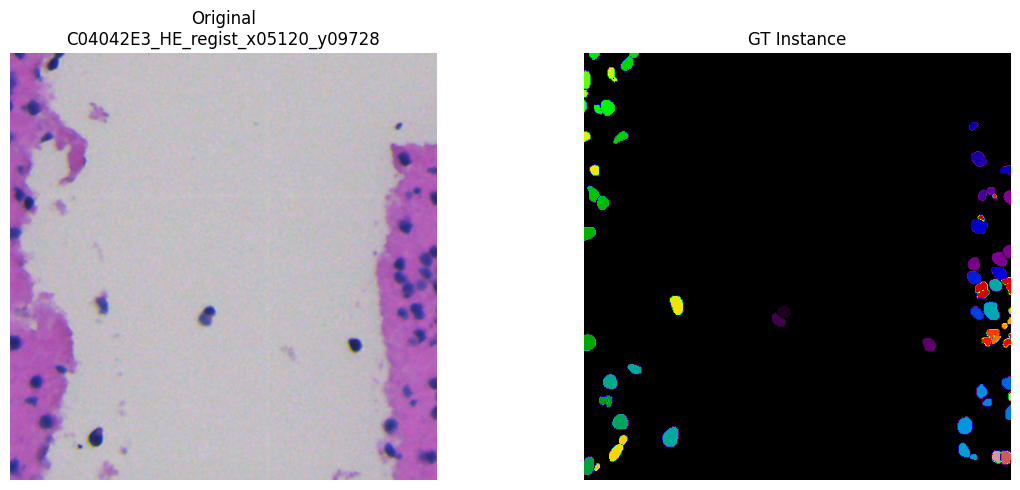

In [9]:
if TUNING_IMAGE_STEM is None:
    tuning_pair = pairs[0]
else:
    stem_to_pair = {p.stem: p for p in pairs}
    if TUNING_IMAGE_STEM not in stem_to_pair:
        raise KeyError(
            f"TUNING_IMAGE_STEM={TUNING_IMAGE_STEM!r} tidak ditemukan. "
            f"Contoh stem yang tersedia: {list(stem_to_pair)[:5]}"
        )
    tuning_pair = stem_to_pair[TUNING_IMAGE_STEM]

tuning_raw_image = load_image_any(tuning_pair.image_path)
tuning_gt = load_instance_mask(tuning_pair.mask_path)

run_config = {
    "image_dir": str(IMAGE_DIR),
    "mask_dir": str(MASK_DIR),
    "output_root": str(OUTPUT_ROOT),
    "model_name": MODEL_NAME,
    "hovernet_repo_root": str(HOVERNET_REPO_ROOT),
    "checkpoint_path": str(CHECKPOINT_PATH),
    "model_mode": MODEL_MODE,
    "nr_types": int(NR_TYPES),
    "type_info_path": str(TYPE_INFO_PATH),
    "tuning_image_stem": tuning_pair.stem,
    "grid_search_space": GRID_SEARCH_SPACE,
    "f1_thresholds": F1_THRESHOLDS,
    "patch_input_shape": int(PATCH_INPUT_SHAPE),
    "patch_output_shape": int(PATCH_OUTPUT_SHAPE),
    "batch_size": int(BATCH_SIZE),
    "nr_inference_workers": int(NR_INFERENCE_WORKERS),
    "nr_post_proc_workers": int(NR_POSTPROC_WORKERS),
    "mem_usage": float(MEM_USAGE),
    "reuse_existing_base_inference": bool(REUSE_EXISTING_BASE_INFERENCE),
}
save_json(RUN_CONFIG_PATH, run_config)
save_json(MODEL_INFO_PATH, model_info)

print("Tuning image :", tuning_pair.stem)
print("Image path   :", tuning_pair.image_path)
print("Mask path    :", tuning_pair.mask_path)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(normalize_for_display(tuning_raw_image))
axes[0].set_title(f"Original\n{tuning_pair.stem}")
axes[0].axis("off")

axes[1].imshow(tuning_gt, cmap="nipy_spectral")
axes[1].set_title("GT Instance")
axes[1].axis("off")

plt.tight_layout()
plt.show()

Tuning .mat    : /data/work/Inference/HoverNet_Clean_GridSearch_V2/01_grid_search/_tuning_base_infer/mat/C04042E3_HE_regist_x05120_y09728.mat
raw_map shape  : (512, 512, 4)
raw_map dtype  : float32
prob_np range  : 1.4176069207394448e-08 -> 0.9997807145118713


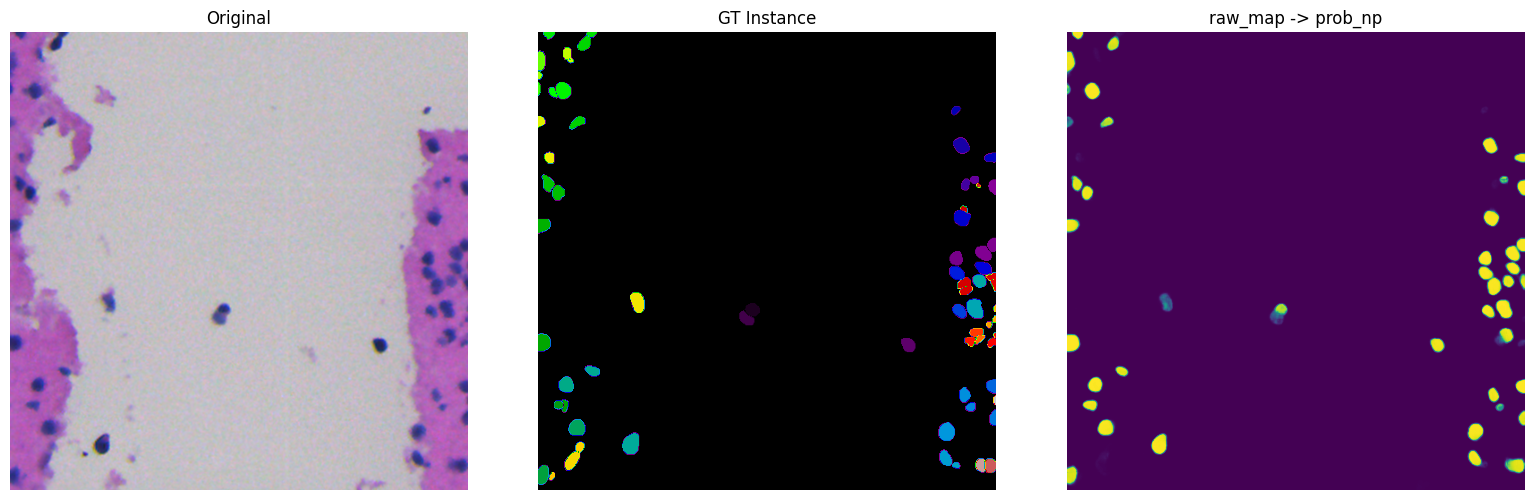

In [10]:
GRID_BASE_INFER_DIR = GRID_DIR / "_tuning_base_infer"
tuning_raw_map, tuning_mat_path = run_hovernet_base_on_single_image(
    tuning_pair.image_path,
    GRID_BASE_INFER_DIR,
    reuse_existing=REUSE_EXISTING_BASE_INFERENCE,
)

tuning_prob_np = extract_prob_np_from_raw_map(tuning_raw_map, NR_TYPES)

print("Tuning .mat    :", tuning_mat_path)
print("raw_map shape  :", tuning_raw_map.shape)
print("raw_map dtype  :", tuning_raw_map.dtype)
print("prob_np range  :", float(tuning_prob_np.min()), "->", float(tuning_prob_np.max()))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(normalize_for_display(tuning_raw_image))
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(tuning_gt, cmap="nipy_spectral")
axes[1].set_title("GT Instance")
axes[1].axis("off")

axes[2].imshow(tuning_prob_np, cmap="viridis")
axes[2].set_title("raw_map -> prob_np")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [11]:
param_names = list(GRID_SEARCH_SPACE.keys())
param_values = [GRID_SEARCH_SPACE[p] for p in param_names]
param_combinations = list(itertools.product(*param_values))

print("Jumlah kombinasi hyperparameter:", len(param_combinations))

grid_records: List[Dict[str, Any]] = []
best_params: Optional[Dict[str, Any]] = None
best_metrics: Optional[Dict[str, float]] = None
best_pred_inst: Optional[np.ndarray] = None
best_key = None

for combo in tqdm(param_combinations, total=len(param_combinations), desc="Grid search HoVer-Net"):
    params = {name: value for name, value in zip(param_names, combo)}

    try:
        pred_inst = hovernet_inst_map_from_raw_map(
            tuning_raw_map,
            NR_TYPES,
            np_thres=float(params["np_thres"]),
            overall_thres=float(params["overall_thres"]),
            min_size=int(params["min_size"]),
            marker_min_size=params["marker_min_size"],
            sobel_ksize=int(params["sobel_ksize"]),
            gauss_ksize=int(params["gauss_ksize"]),
            morph_ksize=int(params["morph_ksize"]),
        )
        metrics = evaluate_case(tuning_gt, pred_inst, thresholds=F1_THRESHOLDS)

        record = dict(params)
        record.update(metrics)
        record["status"] = "ok"
        grid_records.append(record)

        current_key = (
            record["Primary_Score_Mean"],
            record["F1"],
            record["IoU"],
            record["Precision"],
            record["Recall"],
        )
        if best_key is None or current_key > best_key:
            best_key = current_key
            best_params = dict(params)
            best_metrics = dict(metrics)
            best_pred_inst = pred_inst.copy()

    except Exception as exc:
        record = dict(params)
        record.update({
            "Primary_Score_Mean": 0.0,
            "Precision": 0.0,
            "Recall": 0.0,
            "F1": 0.0,
            "IoU": 0.0,
            "Dice": 0.0,
            "AJI": 0.0,
            "PQ": 0.0,
            "DQ": 0.0,
            "SQ": 0.0,
            "N_GT": int(len(np.unique(tuning_gt[tuning_gt > 0]))),
            "N_Pred": 0,
            "Count_Error": -int(len(np.unique(tuning_gt[tuning_gt > 0]))),
            "status": f"error: {exc}",
        })
        grid_records.append(record)

grid_df = pd.DataFrame(grid_records).sort_values(
    by=["Primary_Score_Mean", "F1", "IoU", "Precision", "Recall"],
    ascending=False,
).reset_index(drop=True)

if best_params is None or best_metrics is None or best_pred_inst is None:
    raise RuntimeError("Grid search selesai, tetapi tidak ada kombinasi yang berhasil.")

grid_csv = GRID_DIR / "grid_search_results.csv"
grid_xlsx = GRID_DIR / "grid_search_results.xlsx"
grid_df.to_csv(grid_csv, index=False)

with pd.ExcelWriter(grid_xlsx, engine="openpyxl") as writer:
    grid_df.to_excel(writer, sheet_name="grid_search", index=False)
    pd.DataFrame([best_params]).to_excel(writer, sheet_name="best_params", index=False)
    pd.DataFrame([best_metrics]).to_excel(writer, sheet_name="best_metrics", index=False)

save_json(GRID_DIR / "best_params.json", best_params)
save_json(GRID_DIR / "best_metrics.json", best_metrics)

display(grid_df.head(10))
print("Best params  :", best_params)
print("Best metrics :", {k: best_metrics[k] for k in ['Precision', 'Recall', 'F1', 'IoU', 'Dice', 'AJI', 'PQ', 'DQ', 'SQ'] if k in best_metrics})

tifffile.imwrite(str(GRID_DIR / f"{tuning_pair.stem}_best_pred_instance.tif"), best_pred_inst.astype(np.uint32))
save_binary_png(GRID_DIR / f"{tuning_pair.stem}_best_pred_binary.png", to_binary(best_pred_inst))
save_case_visuals(tuning_raw_image, tuning_gt, best_pred_inst, GRID_DIR, f"{tuning_pair.stem}_best")

Grid search HoVer-Net:   0%|          | 0/605 [00:00<?, ?it/s]

Jumlah kombinasi hyperparameter: 605


Grid search HoVer-Net: 100%|██████████| 605/605 [38:42<00:00,  3.84s/it]


,np_thres,overall_thres,min_size,marker_min_size,sobel_ksize,gauss_ksize,morph_ksize,Precision,Recall,F1,IoU,Dice,Specificity,MCC,TP_pixels,FP_pixels,FN_pixels,TN_pixels,AJI,PQ,DQ,SQ,TP_inst,FP_inst,FN_inst,N_GT,N_Pred,Count_Error,Abs_Count_Error,Rel_Count_Err,Over_Seg_Rate,Under_Seg_Rate,F1@0.3,F1@0.5,F1@0.6,F1@0.7,F1@0.8,F1@0.9,GT_Area_Mean,GT_Area_Std,GT_Area_Med,GT_Circ_Mean,GT_Ecc_Mean,GT_Diam_Mean,Primary_Score_Mean,status,Pred_Area_Mean,Pred_Area_Std,Pred_Area_Med,Pred_Circ_Mean,Pred_Ecc_Mean,Pred_Diam_Mean,AbsDiff_Area_Mean,AbsDiff_Area_Std,AbsDiff_Area_Med,AbsDiff_Circ_Mean,AbsDiff_Ecc_Mean,AbsDiff_Diam_Mean
0,0.1,0.6,5,None,21,3,5,0.958277,0.797596,0.870584,0.770827,0.870584,0.998661,0.869977,7763,338,1970,252073,0.611663,0.607675,0.707965,0.858342,40,3,30,70,43,-27,27,-0.385714,0.042857,0.428571,0.761062,0.707965,0.654867,0.654867,0.584071,0.300885,139.042857,83.016597,128.0,0.938224,0.701998,12.633664,0.849321,ok,188.395349,73.819119,185.0,0.897939,0.669667,15.145878,49.352492,9.197478,57.0,0.040285,0.032331,2.512214
1,0.1,0.6,10,None,21,3,5,0.958277,0.797596,0.870584,0.770827,0.870584,0.998661,0.869977,7763,338,1970,252073,0.611663,0.607675,0.707965,0.858342,40,3,30,70,43,-27,27,-0.385714,0.042857,0.428571,0.761062,0.707965,0.654867,0.654867,0.584071,0.300885,139.042857,83.016597,128.0,0.938224,0.701998,12.633664,0.849321,ok,188.395349,73.819119,185.0,0.897939,0.669667,15.145878,49.352492,9.197478,57.0,0.040285,0.032331,2.512214
2,0.1,0.6,15,None,21,3,5,0.958277,0.797596,0.870584,0.770827,0.870584,0.998661,0.869977,7763,338,1970,252073,0.611663,0.607675,0.707965,0.858342,40,3,30,70,43,-27,27,-0.385714,0.042857,0.428571,0.761062,0.707965,0.654867,0.654867,0.584071,0.300885,139.042857,83.016597,128.0,0.938224,0.701998,12.633664,0.849321,ok,188.395349,73.819119,185.0,0.897939,0.669667,15.145878,49.352492,9.197478,57.0,0.040285,0.032331,2.512214
3,0.1,0.6,20,None,21,3,5,0.958277,0.797596,0.870584,0.770827,0.870584,0.998661,0.869977,7763,338,1970,252073,0.611663,0.607675,0.707965,0.858342,40,3,30,70,43,-27,27,-0.385714,0.042857,0.428571,0.761062,0.707965,0.654867,0.654867,0.584071,0.300885,139.042857,83.016597,128.0,0.938224,0.701998,12.633664,0.849321,ok,188.395349,73.819119,185.0,0.897939,0.669667,15.145878,49.352492,9.197478,57.0,0.040285,0.032331,2.512214
4,0.1,0.6,25,None,21,3,5,0.958277,0.797596,0.870584,0.770827,0.870584,0.998661,0.869977,7763,338,1970,252073,0.611663,0.607675,0.707965,0.858342,40,3,30,70,43,-27,27,-0.385714,0.042857,0.428571,0.761062,0.707965,0.654867,0.654867,0.584071,0.300885,139.042857,83.016597,128.0,0.938224,0.701998,12.633664,0.849321,ok,188.395349,73.819119,185.0,0.897939,0.669667,15.145878,49.352492,9.197478,57.0,0.040285,0.032331,2.512214
5,0.1,0.7,5,None,21,3,5,0.958277,0.797596,0.870584,0.770827,0.870584,0.998661,0.869977,7763,338,1970,252073,0.611663,0.607675,0.707965,0.858342,40,3,30,70,43,-27,27,-0.385714,0.042857,0.428571,0.761062,0.707965,0.654867,0.654867,0.584071,0.300885,139.042857,83.016597,128.0,0.938224,0.701998,12.633664,0.849321,ok,188.395349,73.819119,185.0,0.897939,0.669667,15.145878,49.352492,9.197478,57.0,0.040285,0.032331,2.512214
6,0.1,0.7,10,None,21,3,5,0.958277,0.797596,0.870584,0.770827,0.870584,0.998661,0.869977,7763,338,1970,252073,0.611663,0.607675,0.707965,0.858342,40,3,30,70,43,-27,27,-0.385714,0.042857,0.428571,0.761062,0.707965,0.654867,0.654867,0.584071,0.300885,139.042857,83.016597,128.0,0.938224,0.701998,12.633664,0.849321,ok,188.395349,73.819119,185.0,0.897939,0.669667,15.145878,49.352492,9.197478,57.0,0.040285,0.032331,2.512214
7,0.1,0.7,15,None,21,3,5,0.958277,0.797596,0.870584,0.770827,0.870584,0.998661,0.869977,7763,338,1970,252073,0.611663,0.607675,0.707965,0.858342,40,3,30,70,43,-27,27,-0.385714,0.042857,0.428571,0.761062,0.707965,0.654867,0.654867,0.584071,0.300885,139.042857,83.016597,128.0,0.938224,0.701998,12.633664,0.849321,ok,188.395349,73.819119,185.0,0.897939,0.669667,15.145878,49.352492,9.197478,57.0,0.040285,0.032331,2.512214
8,0.1,0.7

Best params  : {'np_thres': 0.1, 'overall_thres': 0.6, 'min_size': 5, 'marker_min_size': None, 'sobel_ksize': 21, 'gauss_ksize': 3, 'morph_ksize': 5}
Best metrics : {'Precision': 0.958277, 'Recall': 0.797596, 'F1': 0.870584, 'IoU': 0.770827, 'Dice': 0.870584, 'AJI': 0.611663, 'PQ': 0.607675, 'DQ': 0.707965, 'SQ': 0.858342}


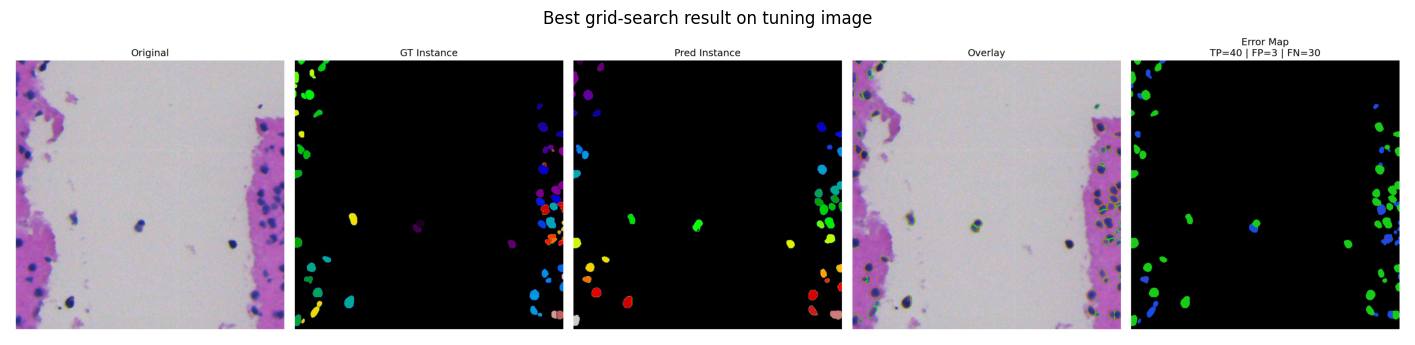

In [12]:
best_panel = GRID_DIR / f"{tuning_pair.stem}_best_panel.png"
if best_panel.exists():
    panel_img = io.imread(str(best_panel))
    plt.figure(figsize=(18, 5))
    plt.imshow(panel_img)
    plt.axis("off")
    plt.title("Best grid-search result on tuning image")
    plt.show()
else:
    print("Panel terbaik belum ditemukan:", best_panel)

In [13]:
all_rows: List[Dict[str, Any]] = []
failed_cases: List[Dict[str, str]] = []

for pair in tqdm(pairs, total=len(pairs), desc="Inferensi semua gambar"):
    raw_image = load_image_any(pair.image_path)
    gt_inst = load_instance_mask(pair.mask_path)

    case_dir = PER_IMAGE_DIR / pair.stem
    case_dir.mkdir(parents=True, exist_ok=True)

    base_hovernet_dir = case_dir / "_hovernet_base_output"

    try:
        raw_map, mat_path = run_hovernet_base_on_single_image(
            pair.image_path,
            base_hovernet_dir,
            reuse_existing=REUSE_EXISTING_BASE_INFERENCE,
        )

        pred_inst = hovernet_inst_map_from_raw_map(
            raw_map,
            NR_TYPES,
            np_thres=float(best_params["np_thres"]),
            overall_thres=float(best_params["overall_thres"]),
            min_size=int(best_params["min_size"]),
            marker_min_size=best_params["marker_min_size"],
            sobel_ksize=int(best_params["sobel_ksize"]),
            gauss_ksize=int(best_params["gauss_ksize"]),
            morph_ksize=int(best_params["morph_ksize"]),
        )

        metrics = evaluate_case(gt_inst, pred_inst, thresholds=F1_THRESHOLDS)
        metrics.update({
            "image_id": pair.stem,
            "image_path": str(pair.image_path),
            "mask_path": str(pair.mask_path),
            "raw_map_mat_path": str(mat_path),
        })
        all_rows.append(metrics)

        tifffile.imwrite(str(case_dir / f"{pair.stem}_pred_instance.tif"), pred_inst.astype(np.uint32))
        save_binary_png(case_dir / f"{pair.stem}_pred_binary.png", to_binary(pred_inst))
        pd.DataFrame([metrics]).to_csv(case_dir / f"{pair.stem}_metrics.csv", index=False)
        save_json(case_dir / f"{pair.stem}_metrics.json", metrics)
        save_case_visuals(raw_image, gt_inst, pred_inst, case_dir, pair.stem)

    except Exception as exc:
        failed_cases.append({
            "image_id": pair.stem,
            "image_path": str(pair.image_path),
            "mask_path": str(pair.mask_path),
            "error": str(exc),
        })

metrics_df = pd.DataFrame(all_rows)
failed_df = pd.DataFrame(failed_cases)

print("Selesai inferensi.")
print("Berhasil :", len(metrics_df))
print("Gagal    :", len(failed_df))
if not failed_df.empty:
    display(failed_df)

Process Patches:   0%|                                    | 0/5 [00:00<?, ?it/s]

[InferManager] using device: cpu


Process Patches:   0%|                                    | 0/5 [00:00<?, ?it/s]

[InferManager] using device: cpu


Process Patches:   0%|                                    | 0/5 [00:00<?, ?it/s]

...

[InferManager] using device: cpu


Process Patches:   0%|                                    | 0/5 [00:00<?, ?it/s]

[InferManager] using device: cpu


Inferensi semua gambar: 100%|██████████| 30/30 [29:25<00:00, 58.86s/it]

Selesai inferensi.
Berhasil : 30
Gagal    : 0


In [ ]:
if metrics_df.empty:
    raise RuntimeError("Tidak ada hasil inferensi yang berhasil, sehingga tidak bisa dibuat rekap.")

id_cols = ["image_id", "image_path", "mask_path", "raw_map_mat_path"]
primary_cols = [
    "Precision", "Recall", "F1", "IoU", "Dice",
    "AJI", "PQ", "DQ", "SQ",
    "Primary_Score_Mean",
    "N_GT", "N_Pred", "Count_Error", "Abs_Count_Error",
    "Rel_Count_Err", "Over_Seg_Rate", "Under_Seg_Rate",
    "Specificity", "MCC",
]
threshold_cols = sorted([c for c in metrics_df.columns if c.startswith("F1@")], key=lambda x: float(x.split("@")[1]))
other_cols = [c for c in metrics_df.columns if c not in id_cols + primary_cols + threshold_cols]
ordered_cols = [c for c in id_cols + primary_cols + threshold_cols + other_cols if c in metrics_df.columns]
metrics_df = metrics_df[ordered_cols].sort_values("image_id").reset_index(drop=True)

numeric_cols = metrics_df.select_dtypes(include=[np.number]).columns.tolist()

mean_row = metrics_df[numeric_cols].mean().to_dict()
std_row = metrics_df[numeric_cols].std(ddof=1).fillna(0).to_dict()

mean_df = pd.DataFrame([mean_row])
mean_df.insert(0, "stat", "mean")

std_df = pd.DataFrame([std_row])
std_df.insert(0, "stat", "std")

aggregate_df = pd.concat([mean_df, std_df], ignore_index=True)

per_image_csv = SUMMARY_DIR / "per_image_metrics.csv"
per_image_xlsx = SUMMARY_DIR / "per_image_metrics.xlsx"
aggregate_csv = SUMMARY_DIR / "aggregate_mean_std.csv"
aggregate_xlsx = SUMMARY_DIR / "aggregate_mean_std.xlsx"
failed_csv = SUMMARY_DIR / "failed_cases.csv"

metrics_df.to_csv(per_image_csv, index=False)
aggregate_df.to_csv(aggregate_csv, index=False)
failed_df.to_csv(failed_csv, index=False)

with pd.ExcelWriter(per_image_xlsx, engine="openpyxl") as writer:
    metrics_df.to_excel(writer, sheet_name="per_image_metrics", index=False)

with pd.ExcelWriter(aggregate_xlsx, engine="openpyxl") as writer:
    aggregate_df.to_excel(writer, sheet_name="mean_std", index=False)
    mean_df.to_excel(writer, sheet_name="mean_only", index=False)
    std_df.to_excel(writer, sheet_name="std_only", index=False)
    pd.DataFrame([best_params]).to_excel(writer, sheet_name="best_params", index=False)
    pd.DataFrame([best_metrics]).to_excel(writer, sheet_name="best_metrics_tuning", index=False)

display(metrics_df.head())
display(aggregate_df)
print("CSV/Excel tersimpan di:", SUMMARY_DIR)

,image_id,image_path,mask_path,raw_map_mat_path,Precision,Recall,F1,IoU,Dice,AJI,PQ,DQ,SQ,Primary_Score_Mean,N_GT,N_Pred,Count_Error,Abs_Count_Error,Rel_Count_Err,Over_Seg_Rate,Under_Seg_Rate,Specificity,MCC,F1@0.3,F1@0.5,F1@0.6,F1@0.7,F1@0.8,F1@0.9,TP_pixels,FP_pixels,FN_pixels,TN_pixels,TP_inst,FP_inst,FN_inst,GT_Area_Mean,GT_Area_Std,GT_Area_Med,GT_Circ_Mean,GT_Ecc_Mean,GT_Diam_Mean,Pred_Area_Mean,Pred_Area_Std,Pred_Area_Med,Pred_Circ_Mean,Pred_Ecc_Mean,Pred_Diam_Mean,AbsDiff_Area_Mean,AbsDiff_Area_Std,AbsDiff_Area_Med,AbsDiff_Circ_Mean,AbsDiff_Ecc_Mean,AbsDiff_Diam_Mean
0,C04042E3_HE_regist_x05120_y09728,/data/work/Inference/Images/C04042E3_HE_regist...,/data/work/Inference/MaskInstance/C04042E3_HE_...,/data/work/Inference/HoverNet_Clean_GridSearch...,0.958277,0.797596,0.870584,0.770827,0.870584,0.611663,0.607675,0.707965,0.858342,0.849321,70,43,-27,27,-0.385714,0.042857,0.428571,0.998661,0.869977,0.761062,0.707965,0.654867,0.654867,0.584071,0.300885,7763,338,1970,252073,40,3,30,139.042857,83.016597,128.0,0.938224,0.701998,12.633664,188.395349,73.819119,185.0,0.897939,0.669667,15.145878,49.352492,9.197478,57.0,0.040285,0.032331,2.512214
1,C04042E3_HE_regist_x07168_y07680,/data/work/Inference/Images/C04042E3_HE_regist...,/data/work/Inference/MaskInstance/C04042E3_HE_...,/data/work/Inference/HoverNet_Clean_GridSearch...,0.872255,0.871894,0.872074,0.773166,0.872074,0.511046,0.562594,0.680556,0.826669,0.847347,178,110,-68,68,-0.382022,0.067416,0.449438,0.984108,0.856156,0.750000,0.680556,0.625000,0.618056,0.534722,0.104167,25298,3705,3717,229424,98,12,80,163.005618,101.426815,149.5,0.937847,0.695553,13.662923,263.663636,142.036697,255.0,0.908000,0.652914,17.701940,100.658018,40.609882,105.5,0.029847,0.042639,4.039017
2,C04042E3_HE_regist_x07168_y14336,/data/work/Inference/Images/C04042E3_HE_regist...,/data/work/Inference/MaskInstance/C04042E3_HE_...,/data/work/Inference/HoverNet_Clean_GridSearch...,0.901873,0.872109,0.886742,0.796528,0.886742,0.508863,0.537110,0.663507,0.809502,0.864313,130,81,-49,49,-0.376923,0.084615,0.461538,0.991582,0.877023,0.758294,0.663507,0.549763,0.540284,0.492891,0.189573,18630,2027,2732,238755,70,11,60,164.323077,94.026282,147.0,0.903994,0.708012,13.865965,255.024691,153.552659,225.0,0.891833,0.683643,17.276146,90.701614,59.526377,78.0,0.012161,0.024369,3.410181
3,C04042E3_HE_regist_x07680_y04608,/data/work/Inference/Images/C04042E3_HE_regist...,/data/work/Inference/MaskInstance/C04042E3_HE_...,/data/work/Inference/HoverNet_Clean_GridSearch...,0.963288,0.742446,0.838571,0.722016,0.838571,0.577476,0.570683,0.704626,0.809909,0.816580,171,110,-61,61,-0.356725,0.064327,0.421053,0.994088,0.819554,0.782918,0.704626,0.676157,0.590747,0.455516,0.135231,33638,1282,11669,215555,99,11,72,264.953216,193.113118,209.0,0.920059,0.664133,17.116045,317.454545,176.170353,283.5,0.899694,0.610010,19.420567,52.501329,16.942765,74.5,0.020365,0.054123,2.304522
4,C04042E3_HE_regist_x07680_y06144,/data/work/Inference/Images/C04042E3_HE_regist...,/data/work/Inference/MaskInstance/C04042E3_HE_...,/data/work/Inference/HoverNet_Clean_GridSearch...,0.910864,0.841399,0.874754,0.777390,0.874754,0.609308,0.616280,0.752688,0.818772,0.851102,162,117,-45,45,-0.277778,0.074074,0.351852,0.988108,0.858355,0.824373,0.752688,0.702509,0.652330,0.537634,0.093190,27836,2724,5247,226337,105,12,57,204.216049,122.428196,174.5,0.925027,0.658010,15.375872,261.196581,142.850902,238.0,0.911552,0.634622,17.598663,56.980532,20.422706,63.5,0.013475,0.023388,2.222791


,stat,Precision,Recall,F1,IoU,Dice,AJI,PQ,DQ,SQ,Primary_Score_Mean,N_GT,N_Pred,Count_Error,Abs_Count_Error,Rel_Count_Err,Over_Seg_Rate,Under_Seg_Rate,Specificity,MCC,F1@0.3,F1@0.5,F1@0.6,F1@0.7,F1@0.8,F1@0.9,TP_pixels,FP_pixels,FN_pixels,TN_pixels,TP_inst,FP_inst,FN_inst,GT_Area_Mean,GT_Area_Std,GT_Area_Med,GT_Circ_Mean,GT_Ecc_Mean,GT_Diam_Mean,Pred_Area_Mean,Pred_Area_Std,Pred_Area_Med,Pred_Circ_Mean,Pred_Ecc_Mean,Pred_Diam_Mean,AbsDiff_Area_Mean,AbsDiff_Area_Std,AbsDiff_Area_Med,AbsDiff_Circ_Mean,AbsDiff_Ecc_Mean,AbsDiff_Diam_Mean
0,mean,0.919265,0.804642,0.856787,0.750607,0.856787,0.570042,0.590699,0.716689,0.823694,0.832825,166.966667,108.266667,-58.70000,58.70000,-0.350296,0.057397,0.407692,0.989968,0.841424,0.777860,0.716689,0.664477,0.621306,0.530827,0.153080,26031.400000,2291.133333,6321.766667,227499.700000,98.600000,9.666667,68.366667,192.743556,116.010269,173.6000,0.929172,0.674580,14.885904,259.001143,136.186625,236.300000,0.909647,0.642005,17.536226,66.257587,25.764899,62.700000,0.019710,0.032738,2.650322
1,std,0.022164,0.055809,0.029999,0.045437,0.029999,0.068530,0.050856,0.053876,0.017034,0.031930,32.958159,21.814158,16.11414,16.11414,0.050350,0.021956,0.059527,0.003692,0.030719,0.041918,0.053876,0.060063,0.056685,0.071834,0.062292,6664.966594,817.536110,2384.468331,8355.055476,20.667482,4.389119,18.923591,28.210037,21.631974,25.8545,0.012868,0.018798,1.081063,30.227769,27.648237,34.484779,0.011522,0.019498,1.036088,19.910914,21.561457,21.946094,0.012674,0.011706,0.709312


CSV/Excel tersimpan di: /data/work/Inference/HoverNet_Clean_GridSearch_V2/03_ringkasan_rata_rata_metrik


Plot ringkasan yang tersimpan:
 - /data/work/Inference/HoverNet_Clean_GridSearch_V2/03_ringkasan_rata_rata_metrik/boxplot_metrics.png
 - /data/work/Inference/HoverNet_Clean_GridSearch_V2/03_ringkasan_rata_rata_metrik/mean_metrics_bar.png
 - /data/work/Inference/HoverNet_Clean_GridSearch_V2/03_ringkasan_rata_rata_metrik/object_f1_threshold_curve.png
 - /data/work/Inference/HoverNet_Clean_GridSearch_V2/03_ringkasan_rata_rata_metrik/cell_count_scatter.png
 - /data/work/Inference/HoverNet_Clean_GridSearch_V2/03_ringkasan_rata_rata_metrik/morphology_summary.png


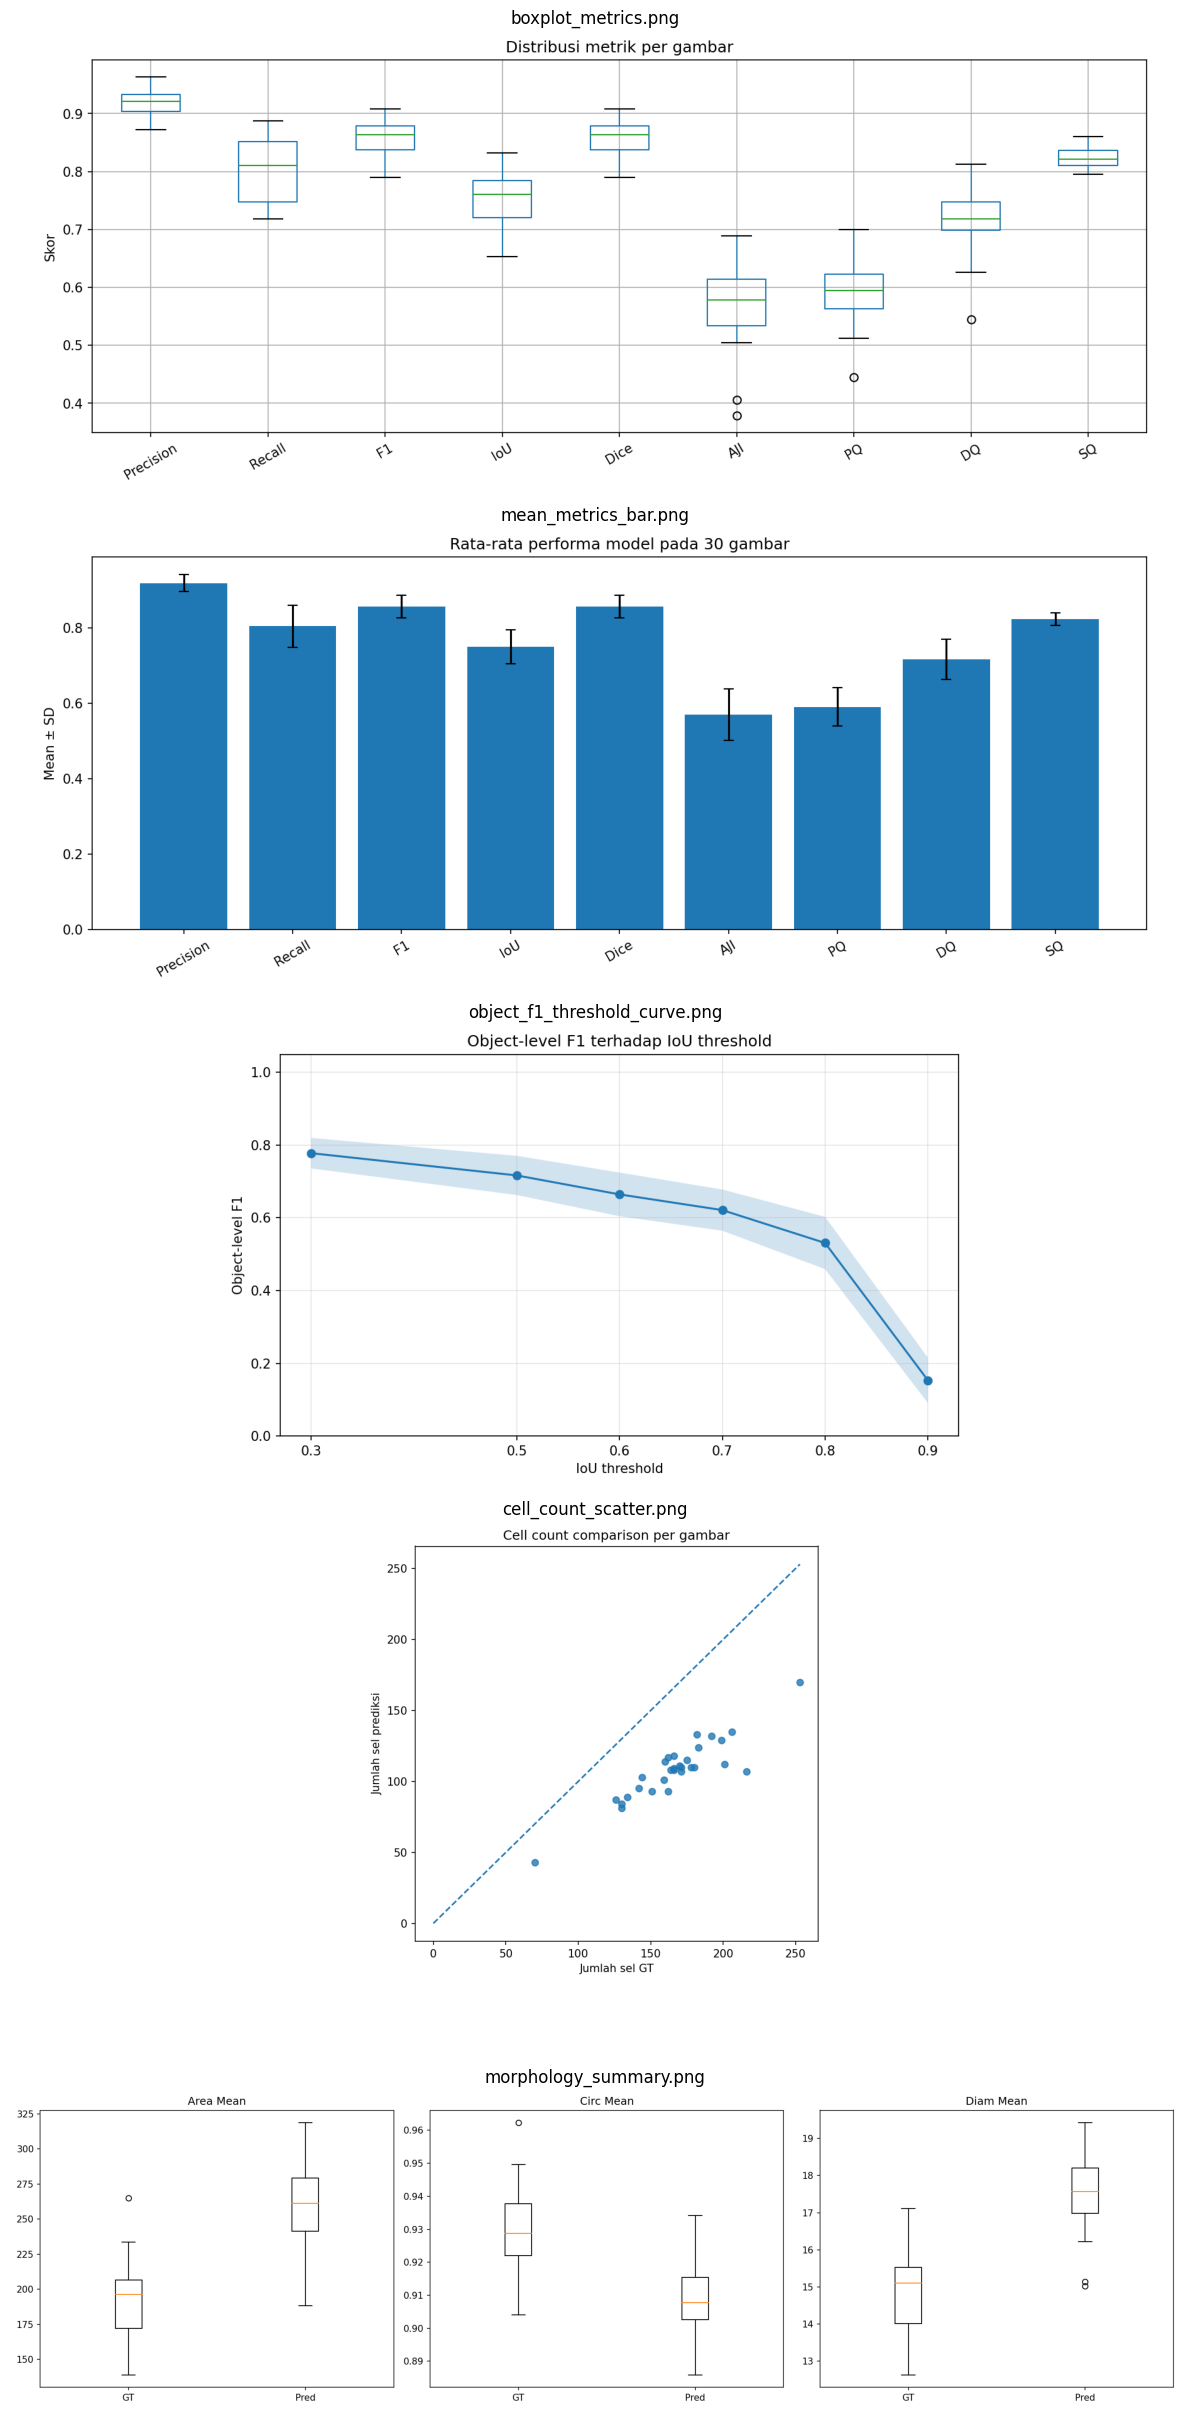

In [ ]:
plot_metric_boxplots(metrics_df, SUMMARY_DIR / "boxplot_metrics.png")
plot_metric_means(metrics_df, SUMMARY_DIR / "mean_metrics_bar.png")
plot_object_f1_curve(metrics_df, SUMMARY_DIR / "object_f1_threshold_curve.png")
plot_cell_count_scatter(metrics_df, SUMMARY_DIR / "cell_count_scatter.png")
plot_morphology_summary(metrics_df, SUMMARY_DIR / "morphology_summary.png")

summary_preview_paths = [
    SUMMARY_DIR / "boxplot_metrics.png",
    SUMMARY_DIR / "mean_metrics_bar.png",
    SUMMARY_DIR / "object_f1_threshold_curve.png",
    SUMMARY_DIR / "cell_count_scatter.png",
    SUMMARY_DIR / "morphology_summary.png",
]

existing = [p for p in summary_preview_paths if p.exists()]
print("Plot ringkasan yang tersimpan:")
for p in existing:
    print(" -", p)

if existing:
    fig, axes = plt.subplots(len(existing), 1, figsize=(12, 5 * max(len(existing), 1)))
    if len(existing) == 1:
        axes = [axes]

    for ax, img_path in zip(axes, existing):
        ax.imshow(io.imread(str(img_path)))
        ax.set_title(img_path.name)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

## Struktur output notebook

Notebook ini akan menghasilkan struktur folder seperti berikut:

```text
OUTPUT_ROOT/
├── paired_input_files.csv
├── run_config.json
├── model_resolution_info.json
├── 01_grid_search/
│   ├── _tuning_base_infer/
│   │   └── mat/
│   │       └── <tuning_stem>.mat
│   ├── grid_search_results.csv
│   ├── grid_search_results.xlsx
│   ├── best_params.json
│   ├── best_metrics.json
│   ├── <tuning_stem>_best_pred_instance.tif
│   ├── <tuning_stem>_best_pred_binary.png
│   ├── <tuning_stem>_best_panel.png
│   ├── <tuning_stem>_best_overlay.png
│   └── <tuning_stem>_best_error_map.png
├── 02_hasil_inferensi_per_gambar/
│   ├── <image_stem_1>/
│   │   ├── _hovernet_base_output/
│   │   │   └── mat/
│   │   │       └── <image_stem_1>.mat
│   │   ├── <image_stem_1>_pred_instance.tif
│   │   ├── <image_stem_1>_pred_binary.png
│   │   ├── <image_stem_1>_metrics.csv
│   │   ├── <image_stem_1>_metrics.json
│   │   ├── <image_stem_1>_panel.png
│   │   ├── <image_stem_1>_overlay.png
│   │   └── <image_stem_1>_error_map.png
│   └── ...
└── 03_ringkasan_rata_rata_metrik/
    ├── per_image_metrics.csv
    ├── per_image_metrics.xlsx
    ├── aggregate_mean_std.csv
    ├── aggregate_mean_std.xlsx
    ├── failed_cases.csv
    ├── boxplot_metrics.png
    ├── mean_metrics_bar.png
    ├── object_f1_threshold_curve.png
    ├── cell_count_scatter.png
    └── morphology_summary.png
```

## Hyperparameter HoVer-Net yang diekspos di notebook ini

Hyperparameter **post-processing** yang tersedia di `GRID_SEARCH_SPACE`:

1. `np_thres`  
2. `overall_thres`  
3. `min_size`  
4. `marker_min_size`  
5. `sobel_ksize`  
6. `gauss_ksize`  
7. `morph_ksize`  

Default notebook ini memvariasikan **3 parameter utama** (`np_thres`, `overall_thres`, `min_size`) dan menjaga 4 parameter lain pada default resmi HoVer-Net agar total grid search tetap masuk akal.